In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

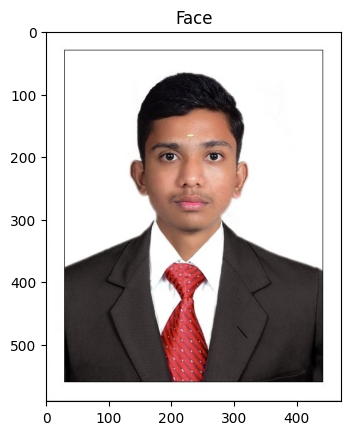

In [2]:
# Load the Face Image
faceImage = cv2.imread('my_photo.jpg')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(591, 472, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(591, 472, 3)

Text(0.5, 1.0, 'glassPNG')

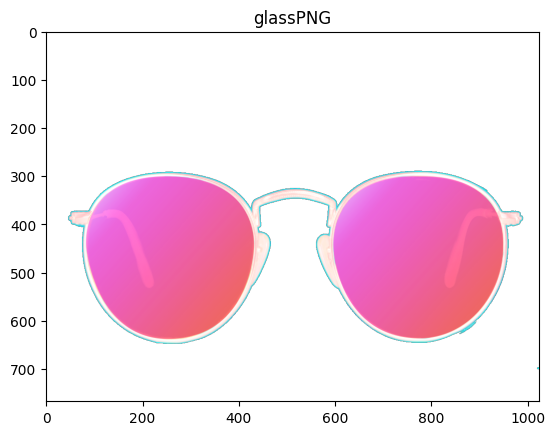

In [8]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('sunglass.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

In [9]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))

image Dimension =(50, 190, 4)


In [10]:
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]

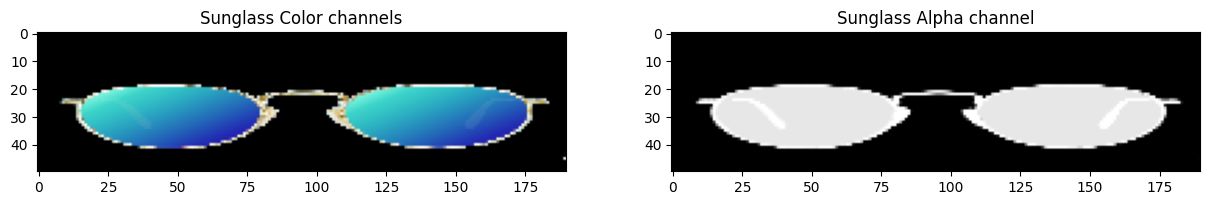

In [11]:
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Color channels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alpha channel');

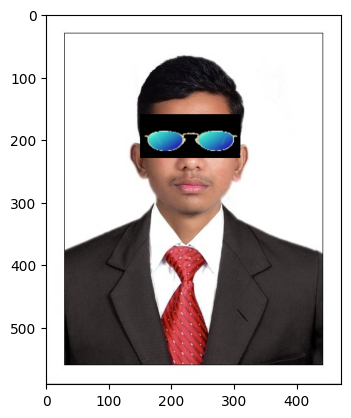

In [26]:
faceWithGlassesNaive = faceImage.copy()

faceWithGlassesNaive[160:230, 150:310] = glassBGR

plt.imshow(faceWithGlassesNaive[..., ::-1])

(np.float64(-0.5), np.float64(159.5), np.float64(69.5), np.float64(-0.5))

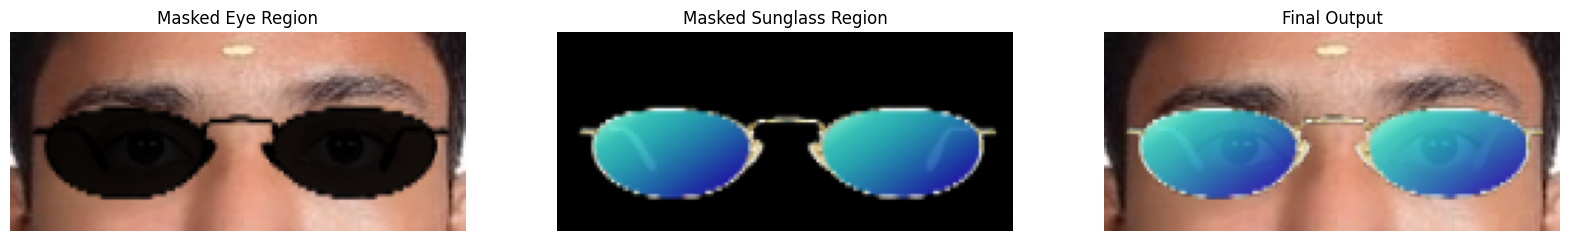

In [33]:
# Resize mask to match glasses size
glassMask1 = cv2.resize(glassMask1, (160, 70))

# Convert mask to 3 channels and normalize to [0,1] as float
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1)).astype(np.float32) / 255.0

# Make a copy of the face image
faceWithGlassesArithmetic = faceImage.copy()

# Define ROI (must match 70x160)
y1, y2 = 160, 230
x1, x2 = 150, 310

eyeROI = faceWithGlassesArithmetic[y1:y2, x1:x2].astype(np.float32)
glass   = glassBGR.astype(np.float32)

# Apply masking (float blending)
maskedEye   = cv2.multiply(eyeROI, (1.0 - glassMask))
maskedGlass = cv2.multiply(glass,  glassMask)

# Combine and convert back to uint8
eyeRoiFinal = cv2.add(maskedEye, maskedGlass).astype(np.uint8)

# Put back into original image
faceWithGlassesArithmetic[y1:y2, x1:x2] = eyeRoiFinal

# Display results
plt.figure(figsize=[20,20])
plt.subplot(131); plt.imshow(maskedEye.astype(np.uint8)[...,::-1]); plt.title("Masked Eye Region"); plt.axis('off')
plt.subplot(132); plt.imshow(maskedGlass.astype(np.uint8)[...,::-1]); plt.title("Masked Sunglass Region"); plt.axis('off')
plt.subplot(133); plt.imshow(eyeRoiFinal[...,::-1]); plt.title("Final Output"); plt.axis('off')

Text(0.5, 1.0, 'With Sunglasses')

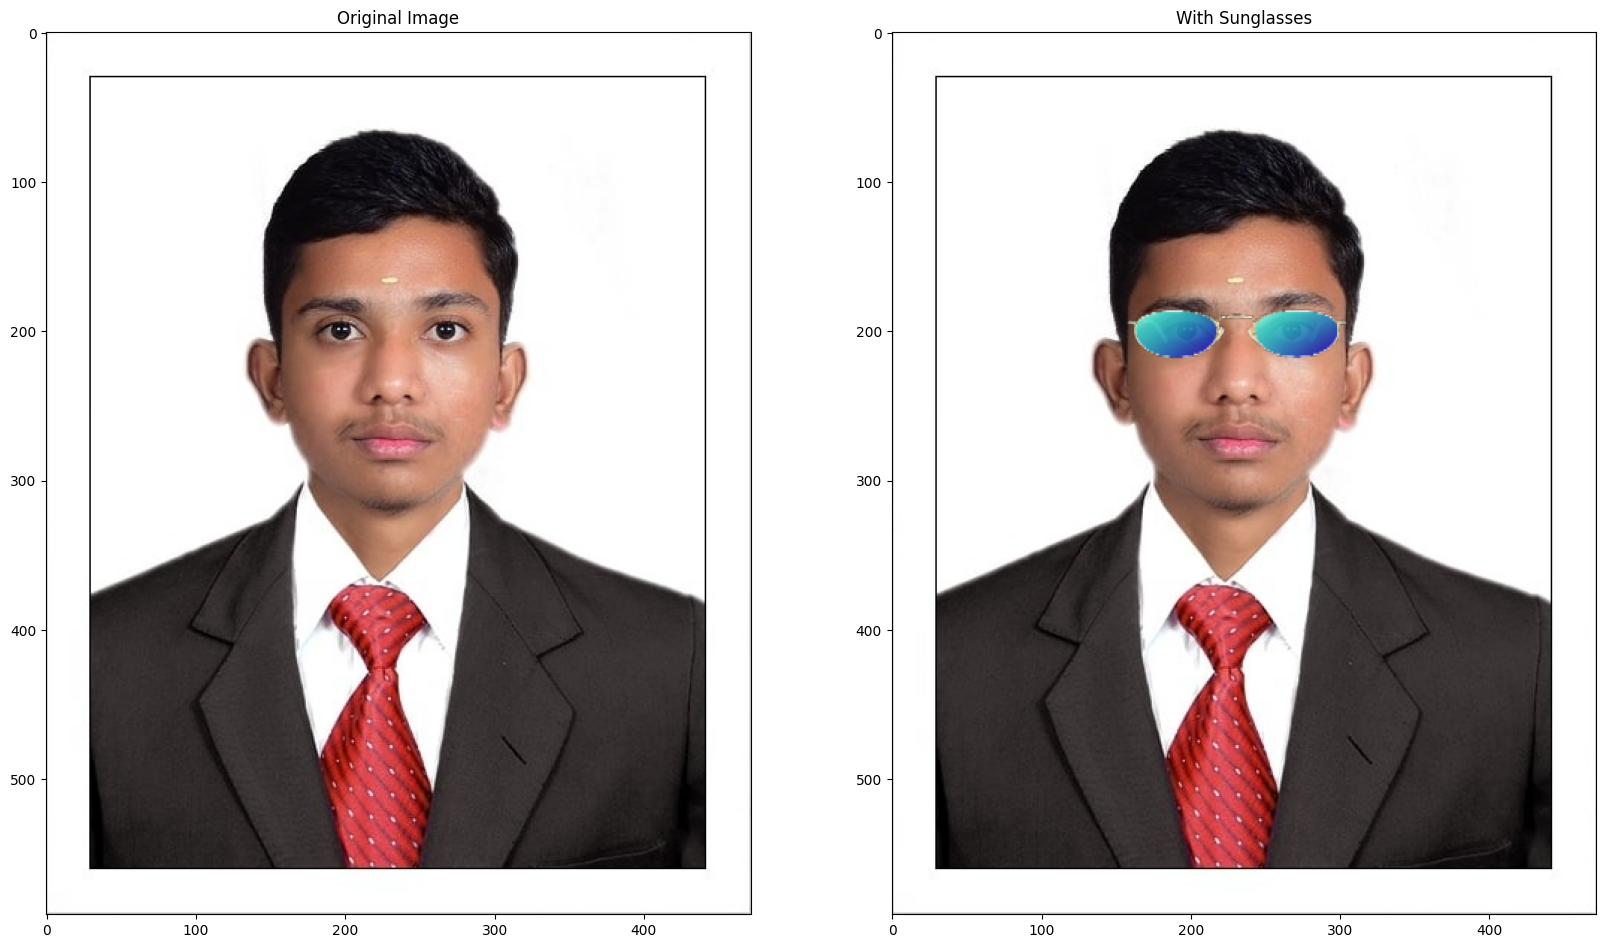

In [34]:
faceWithGlassesArithmetic[160:230,150:310] = eyeRoiFinal

plt.figure(figsize=[20,20])
plt.subplot(121); plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(faceWithGlassesArithmetic[:,:,::-1]); plt.title("With Sunglasses")